<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Math & Python Refresher — From Curve Fitting to Real Seismic Noise

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 3 — Math and Python Refresher**

This notebook combines everything from Lecture 3's Python tools into one workflow:

1. **Least-squares curve fitting** — the linear-algebra idea underneath almost every inverse problem in seismology.
2. **Downloading real waveform data** from the EarthScope archive (building on Lecture 2's SEED codes and instrument response).
3. **Power spectral density (PSD)** — first on synthetic noise, then on a real seismogram.
4. **Probabilistic power spectral densities (PPSDs)** — ObsPy's built-in tool for characterizing a station's long-term noise behavior.

> **Note:** cells that call EarthScope's web services require internet access and will not run in a sandboxed/offline environment. Everything else runs anywhere with the packages below installed.

## 0. Setup

You'll need `numpy`, `scipy`, `matplotlib`, `obspy`, and `colorednoise`.

In [1]:
# Run once per environment
%pip install numpy scipy matplotlib obspy colorednoise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 39.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (9, 4)

## Part 1 — Least-Squares Curve Fitting

Almost every "inverse problem" in seismology — locating an earthquake, imaging velocity structure, estimating a source mechanism — comes down to fitting a model to noisy data. The simplest version is ordinary least squares.

We'll generate noisy data from a known quadratic, $y = ax^2 + bx + c$, then recover $(a, b, c)$ by solving a linear system.

In [3]:
x = np.linspace(0, 100, num=101)
print(x[:10], "...")

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.] ...


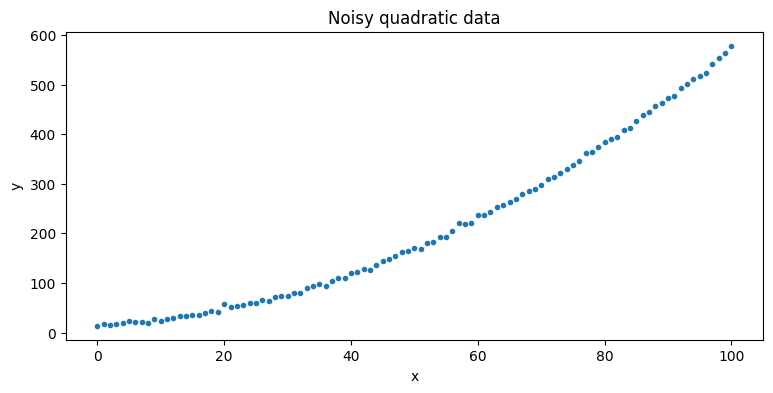

In [4]:
# True coefficients
a, b, c = 0.05, 0.6, 14

# Noise whose *size* varies from point to point (heteroscedastic noise) —
# we'll use this later to demonstrate weighted least squares.
variance = np.random.rand(len(x)) + 0.5
y = a * x * x + b * x + c + np.random.randn(len(x)) * 3 * variance

plt.plot(x, y, 'o', markersize=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy quadratic data")
plt.show()

To solve for $(a, b, c)$, write the problem as a linear system $\mathbf{A}\mathbf{m} = \mathbf{y}$, where each row of $\mathbf{A}$ is $[x_i^2,\ x_i,\ 1]$ and $\mathbf{m} = [a, b, c]^T$ is the model we're solving for.

In [5]:
A = np.zeros((len(x), 3))
for i in range(len(x)):
    A[i, 0] = x[i] * x[i]
    A[i, 1] = x[i]
    A[i, 2] = 1

In [6]:
M = np.linalg.lstsq(A, y, rcond=None)[0]
print("Recovered [a, b, c]:", M)
print("True      [a, b, c]:", [a, b, c])

Recovered [a, b, c]: [ 0.05002459  0.56911551 15.4551251 ]
True      [a, b, c]: [0.05, 0.6, 14]


### Weighted least squares

Ordinary least squares treats every data point as equally trustworthy. But we built `y` with per-point noise `variance` — some points are noisier than others. **Weighted** least squares down-weights the noisy points using a weight matrix $\mathbf{W}$ (here, $W_{ii} = 1/\text{variance}_i$), solving $\mathbf{W}\mathbf{A}\mathbf{m} = \mathbf{W}\mathbf{y}$ instead.

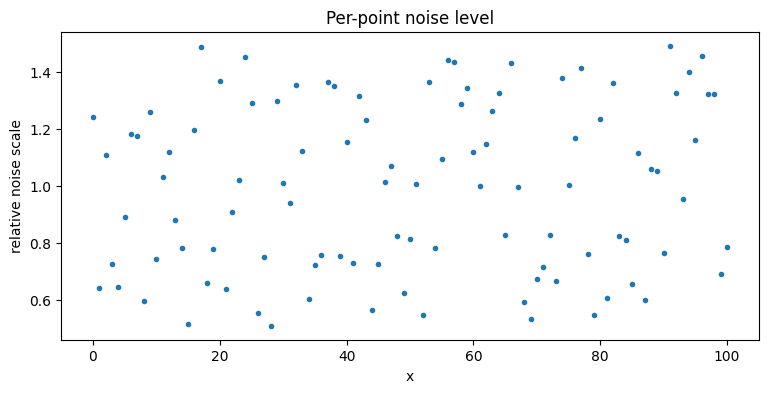

In [7]:
plt.plot(x, variance, 'o', markersize=3)
plt.xlabel("x")
plt.ylabel("relative noise scale")
plt.title("Per-point noise level")
plt.show()

In [8]:
# Build the (diagonal) weight matrix
W = np.zeros((len(x), len(x)))
for i in range(len(x)):
    W[i, i] = 1 / variance[i]

# Weighted least squares
M_weighted = np.linalg.lstsq(np.dot(W, A), np.dot(W, y), rcond=None)[0]

print("Unweighted [a, b, c]:", M)
print("Weighted   [a, b, c]:", M_weighted)
print("True       [a, b, c]:", [a, b, c])

Unweighted [a, b, c]: [ 0.05002459  0.56911551 15.4551251 ]
Weighted   [a, b, c]: [ 0.05027114  0.5494563  15.58742506]
True       [a, b, c]: [0.05, 0.6, 14]


## Part 2 — Downloading Real Waveform Data from EarthScope

Now let's move from synthetic data to a real earthquake recording, using the same FDSN tools from Lecture 2's notebook. We'll look at the **2021-07-29 M8.2 Chignik, Alaska earthquake** recorded at station `AK.CHN`.

In [9]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

client = Client("EARTHSCOPE")

# Station information (see Lecture 2 for the SEED channel-naming convention)
net = "AK"       # Alaska network
sta = "CHN"
loc = ""         # location code — empty/null here
chan_N = "BNN"   # north component, strong-motion accelerometer band
chan_E = "BNE"
chan_Z = "BNZ"

In [10]:
# https://earthquake.usgs.gov/earthquakes/eventpage/ak0219neiszm/executive
event_time = UTCDateTime("2021-07-29T06:15:49")
starttime = event_time
endtime = event_time + 120   # 2 minutes of data

# attach_response=True bundles the instrument response with the waveform
my_stream = client.get_waveforms(net, sta, loc, chan_N, starttime, endtime,
                                  attach_response=True)
print(my_stream)

/tmp/ipykernel_2129/3221657823.py:7: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  my_stream = client.get_waveforms(net, sta, loc, chan_N, starttime, endtime,


1 Trace(s) in Stream:
AK.CHN..BNN | 2021-07-29T06:15:49.008400Z - 2021-07-29T06:17:48.988400Z | 50.0 Hz, 6000 samples


### Removing the instrument response

Exactly as in Lecture 2: convert from raw digitizer counts into physical units (here, acceleration) using the attached instrument response.

In [11]:
st_acc = my_stream.copy()
st_acc.remove_response(output="ACC")   # could also use "DISP" or "VEL"
print(st_acc)

1 Trace(s) in Stream:
AK.CHN..BNN | 2021-07-29T06:15:49.008400Z - 2021-07-29T06:17:48.988400Z | 50.0 Hz, 6000 samples


In [12]:
tr = st_acc[0]              # the Trace within the Stream
data = tr.data              # numpy array of the waveform
time = tr.times()           # numpy array of time values (seconds)
print(tr.stats)

               network: AK
               station: CHN
              location: 
               channel: BNN
             starttime: 2021-07-29T06:15:49.008400Z
               endtime: 2021-07-29T06:17:48.988400Z
         sampling_rate: 50.0
                 delta: 0.02
                  npts: 6000
                 calib: 1.0
_fdsnws_dataselect_url: https://service.earthscope.org/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 34, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 17408})
            processing: ['ObsPy 1.5.1: trim(endtime=UTCDateTime(2021, 7, 29, 6, 17, 49, 8400)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2021, 7, 29, 6, 15, 49, 8400))', "ObsPy 1.5.1: remove_response(fig=None::inventory=None::output='ACC'::plot=False::pre_filt=None::taper=True::taper_fraction=0.05::water_level=60::zero_mean=True)"]
              response: Channel Resp

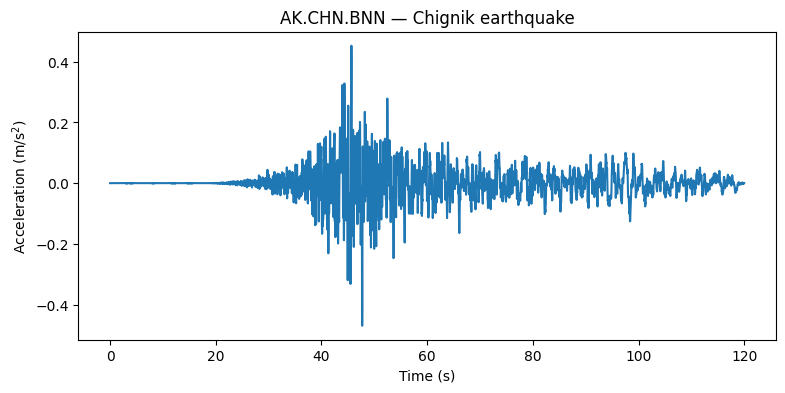

In [13]:
plt.plot(time, data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s$^2$)")
plt.title(f"{net}.{sta}.{chan_N} — Chignik earthquake")
plt.show()

ObsPy can also save a formatted plot directly, and write the trace out to SAC or MiniSEED for use in other software (e.g. GMT).

In [14]:
plotfile = f"{net}.{sta}.{chan_N}.png"
st_acc.plot(
    outfile=plotfile, size=(800, 250), dpi=100,
    color="blue", bgcolor="white", face_color="white",
    number_of_ticks=6, tick_rotation=45,
    type="relative", linewidth=0.5, linestyle="-",
)

st_acc.write(f"{net}.{sta}.{chan_N}.acc.sac", format="SAC")

## Part 3 — Power Spectral Density

### 3a. PSDs of synthetic noise

Before computing a PSD on real data, let's build intuition with synthetic noise. `scipy.signal.welch` estimates the PSD by averaging the periodogram over overlapping windows (Welch's method) — the same segment-averaging idea behind the McNamara & Buland PSD estimator discussed in lecture.

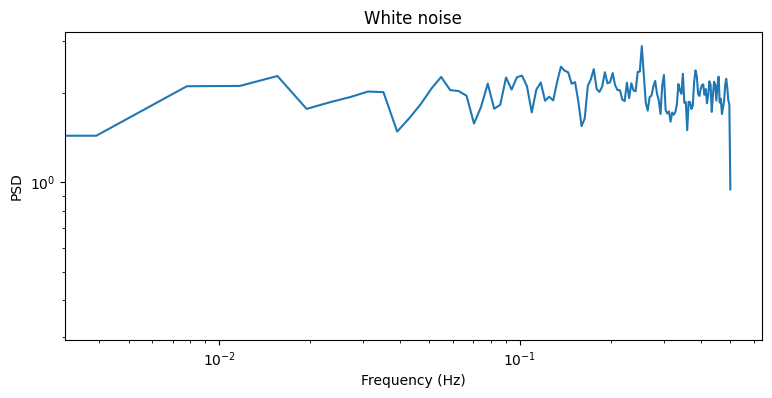

In [15]:
from scipy import signal

white = np.random.randn(10000)   # white noise
fE, PE = signal.welch(white, 1, window='hann')

plt.loglog(fE, PE)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("White noise")
plt.show()

**Colored noise** has a PSD that follows a power law, $S(f) \propto 1/f^{\beta}$. Seismic and many other natural noise processes are rarely perfectly white — flicker noise ($\beta=1$) and random-walk noise ($\beta=2$) are common models.

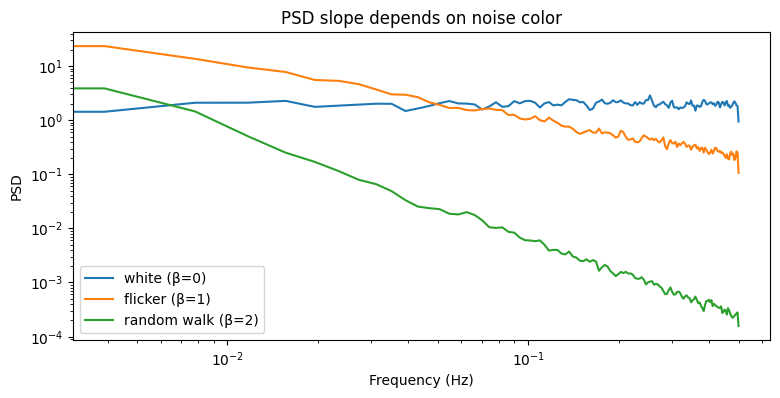

In [16]:
import colorednoise as cn

flicker = cn.powerlaw_psd_gaussian(1, 10000)      # beta = 1: flicker noise
random_walk = cn.powerlaw_psd_gaussian(2, 10000)  # beta = 2: random walk (Brownian) noise

fE1, PE1 = signal.welch(flicker, 1, window='hann')
fE2, PE2 = signal.welch(random_walk, 1, window='hann')

plt.loglog(fE, PE, label="white (β=0)")
plt.loglog(fE1, PE1, label="flicker (β=1)")
plt.loglog(fE2, PE2, label="random walk (β=2)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.title("PSD slope depends on noise color")
plt.show()

### 3b. PSD of the real earthquake waveform

Now apply the same `welch()` approach to the Chignik earthquake data downloaded in Part 2, and compare it to a PSD computed from an hour of *pre-event* data at the same station — i.e. ambient background noise rather than earthquake signal.

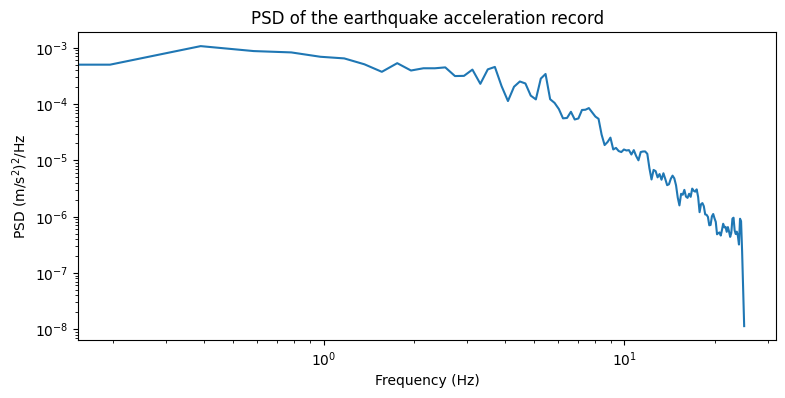

In [17]:
fE, PE = signal.welch(data, 50, window='hann')  # 50 Hz sample rate

plt.loglog(fE, PE)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (m/s$^2$)$^2$/Hz")
plt.title("PSD of the earthquake acceleration record")
plt.show()

/tmp/ipykernel_2129/727737978.py:5: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  noise_stream = client.get_waveforms(net, sta, loc, chan_N, noise_start, noise_end,


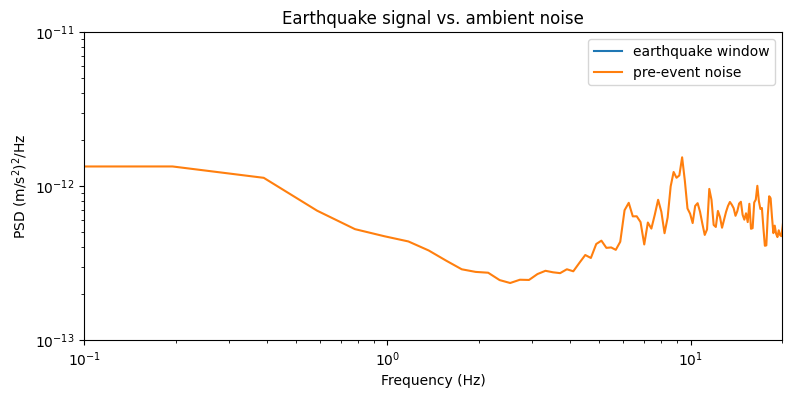

In [18]:
# One hour of data starting well before the earthquake origin time
noise_start = UTCDateTime("2021-07-29T04:15:49")
noise_end = noise_start + 3600

noise_stream = client.get_waveforms(net, sta, loc, chan_N, noise_start, noise_end,
                                     attach_response=True)
noise_acc = noise_stream.copy()
noise_acc.remove_response(output="ACC")
noise_data = noise_acc[0].data

fE_noise, PE_noise = signal.welch(noise_data, 50, window='hann')

plt.loglog(fE, PE, label="earthquake window")
plt.loglog(fE_noise, PE_noise, label="pre-event noise")
plt.xlim((0.1, 20))
plt.ylim((1e-13, 1e-11))
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (m/s$^2$)$^2$/Hz")
plt.legend()
plt.title("Earthquake signal vs. ambient noise")
plt.show()

## Part 4 — Probabilistic Power Spectral Density (PPSD)

A single PSD only describes one time window. To characterize a station's *typical* noise behavior — the way the McNamara & Buland (2004) probabilistic PSD figure does — ObsPy's `PPSD` class computes many overlapping PSD segments and builds up a probability density function of power vs. period.

In [19]:
from obspy import read, read_inventory
from obspy.io.xseed import Parser
from obspy.signal import PPSD

# Example data bundled with ObsPy's documentation
st_example = read("https://examples.obspy.org/BW.KW1..EHZ.D.2011.037")
tr_example = st_example.select(id="BW.KW1..EHZ")[0]

inv_example = read_inventory("https://examples.obspy.org/BW_KW1.xml")

In [20]:
ppsd = PPSD(tr_example.stats, metadata=inv_example)
ppsd.add(st_example)

print("Number of PSD segments:", len(ppsd.times_processed))

Number of PSD segments: 47


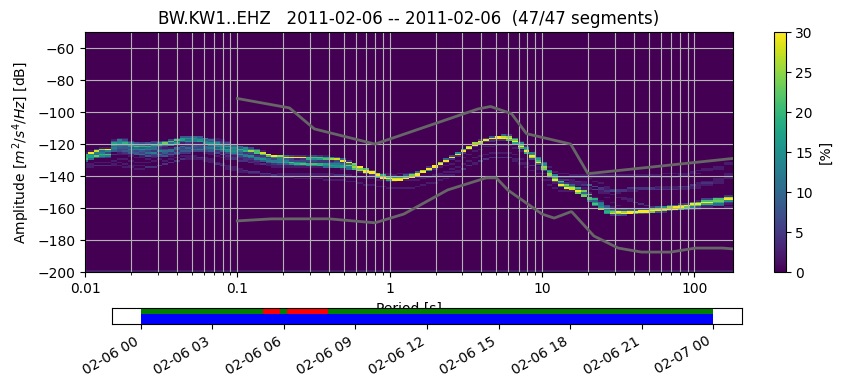

In [21]:
ppsd.plot()

In practice you'd feed a `PPSD` object weeks or months of continuous data — each added segment builds up the probability density, producing the same kind of banded, high/low-noise-model plot shown in lecture for station AHID.

## Summary & Further Resources

- **Least squares** — `numpy.linalg.lstsq`; weight the system to account for heteroscedastic data.
- **EarthScope data access** — `obspy.clients.fdsn.Client`, `get_waveforms()`, `remove_response()` (see also Lecture 2's notebook).
- **PSDs** — `scipy.signal.welch` for a quick estimate; ObsPy's `PPSD` class for a station's long-term probabilistic noise characterization.
- **SEED / MiniSEED / SAC I/O** — `Stream.write(..., format="SAC")` or `"MSEED"`; `Trace.data` gives you a plain NumPy array for use with other tools (e.g. GMT).

**Links:**
- ObsPy documentation: https://docs.obspy.org/
- `scipy.signal.welch`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
- McNamara & Buland (2004), *Ambient Noise Levels in the Continental United States*, BSSA 94(4): 1517–1527
- Continuous wavelet transform (`scipy.signal.cwt`): https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.signal.cwt.html
- PNSN spectrogram tutorial: https://docs.obspy.org/tutorial/code_snippets/plotting_spectrograms.html